# Last-Call — a quantitative teardown 🔬
### TOM vs non-TOM with a t-stat · the rf-consistent window race · the time-in-market illusion · tested sub-period decay

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Still alive?: Faded](https://img.shields.io/badge/Still_alive%3F-Faded-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We confirm the turn-of-the-month effect on the S&P 500 back to 1950, then test whether it pays to trade — holding the exact calendar window, crediting the cash leg, and comparing excess to excess.

> ⚠️ **Not investment advice.** ^GSPC daily 1950–2026 (price-only index — fine for a TOM-vs-rest *difference*, stated rather than mislabelled) + SPY 1993–2026 (auto-adjusted = total return) + ^IRX, Yahoo. Sources in [`docs/references.md`](../docs/references.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (last_call/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from last_call import data, strategy as st
gspc = data.fetch_prices("^GSPC", start_year=1950)   # effect (price-only index)
spy  = data.fetch_prices("SPY", start_year=1993)     # tradable (total return)
rf   = data.fetch_tbill().reindex(spy.index).ffill().fillna(0.0)  # the cash leg (^IRX/252)
d = st.tom_vs_rest(gspc)


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| Signal | **Real** | TOM 11.0 vs non-TOM 1.9 bp/day, Welch t 5.1 |
| Tradability | **Mirage** | excess-of-cash Sharpe 0.41 (gross) < buy-and-hold 0.51; CAGR 5.5% vs 10.8% |
| Still alive? | **Faded** | premium 11.7 → 0.6 bp/day across 2008; change t 2.3, modern t 0.1 |

> 💡 *In plain words:* real per-day edge, but you can't compound a calendar you're absent from — and the edge itself has gone to zero since 2008.

## 1 · The claim, steelmanned

- **H₁:** mean return on TOM days exceeds non-TOM days (significantly).
- **H₂ (the pitch):** a long-window-else-cash book beats buy-and-hold on a like-for-like footing.
- **H₃:** the effect is stable over time.

## 2 · So what? — what rides on each

If H₂ holds you get equity returns at a fraction of the risk-time. If only H₁ holds it's a true fact that doesn't pay; if H₃ fails it's a fact that *stopped* paying.

## 3 · How we'd know — the protocol

Mark [-1,+3] → TOM vs non-TOM means + Welch t → the tradable rule. Two methodological points the naive backtest gets wrong: **(a) no signal lag** — the window is a deterministic function of the exchange calendar, known before the month begins, so the position for day t goes on at the close of day t−1 and the book holds exactly the masked days (lagging the mask trades the *wrong* window: it misses day −1, the richest day, and holds day +4); **(b) rf consistency** — a book that idles in cash 81% of the time cannot be raced on raw Sharpe against an always-invested index, so the cash leg earns the T-bill and the Sharpe race is excess-of-cash on both sides. Then split 1950–87 / 1988–2007 / 2008-on and *test* the decay (Welch on each slice + a Welch test on the change in premium).

## 4 · The teardown

### 4.1 The effect, with a t-stat

In [2]:
print({k: (round(v,2) if isinstance(v,float) else v) for k,v in d.items()})
print(f"TOM {d['tom_bp']:.1f} bp/day vs non-TOM {d['rest_bp']:.1f} bp/day — Welch t = {d['welch_t']:.1f} "
      f"({d['n_tom']} TOM days, {d['n_rest']} rest, {d['n_tom']+d['n_rest']} total)")

{'tom_bp': 10.99, 'rest_bp': 1.92, 'all_bp': 3.65, 'n_tom': 3672, 'n_rest': 15560, 'tom_share': 0.19, 'welch_t': 5.07}
TOM 11.0 bp/day vs non-TOM 1.9 bp/day — Welch t = 5.1 (3672 TOM days, 15560 rest, 19232 total)


> 💡 *In plain words:* t≈5 over 76 years — the concentration is not luck. **H₁ holds.**

### 4.2 The window-vs-buy-and-hold race, rf-consistent and after costs

Cash leg credited at the T-bill; Sharpe quoted raw **and** excess-of-cash. Watch the raw column mislead: the window book's raw Sharpe beats buy-and-hold's — entirely because 81% of its days bank the cash rate at near-zero vol. Strip the T-bill from both sides and the ranking flips back.

In [3]:
rows={}
for c in (0.0,2.0,5.0):
    book = st.tom_returns(spy,c,rf=rf)
    rows[f'TOM-only {c:.0f}bp'] = {'cagr': st.summary(book)['cagr'], 'sharpe_raw': st.summary(book)['sharpe'],
                                   'sharpe_excess': st.summary(book, rf=rf)['sharpe'],
                                   'max_drawdown': st.summary(book)['max_drawdown'], 'in_market': st.tom_mask(spy.index).mean()}
bh = st.buy_hold(spy)
rows['Buy & hold SPY'] = {'cagr': st.summary(bh)['cagr'], 'sharpe_raw': st.summary(bh)['sharpe'],
                          'sharpe_excess': st.summary(bh, rf=rf)['sharpe'],
                          'max_drawdown': st.summary(bh)['max_drawdown'], 'in_market': 1.0}
display(pd.DataFrame(rows).T.round(3))

,cagr,sharpe_raw,sharpe_excess,max_drawdown,in_market
TOM-only 0bp,0.055,0.720,0.408,-0.178,0.191
TOM-only 2bp,0.050,0.659,0.347,-0.180,0.191
TOM-only 5bp,0.043,0.567,0.255,-0.183,0.191
Buy & hold SPY,0.108,0.643,0.510,-0.552,1.000


> 💡 *In plain words:* even gross, on the honest footing — exact window, cash credited, excess vs excess — the window book's Sharpe (0.41) trails buy-and-hold (0.51), and it compounds half as fast (5.5% vs 10.8%/yr); costs (12 round-trips/yr) push it lower still. **H₂ rejected** — a per-day edge you're absent from 80% of the time doesn't compound, and the raw-Sharpe flattery was the T-bill, not the anomaly.

### 4.3 The decay — tested, not asserted

,tom_bp,rest_bp,welch_t
1950-1987,13.77,0.67,6.16
1988-2007,11.45,2.28,2.56
2008-on,4.77,4.12,0.14


premium 11.7 bp/day pre-2008 (t=6.3) -> 0.6 bp/day 2008-on (t=0.1); change t=2.26


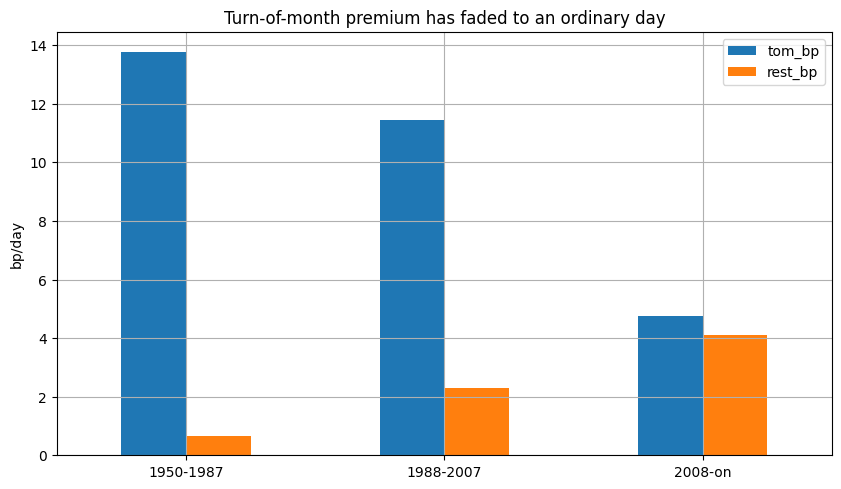

In [4]:
labs=[('1950-1987',1950,1987),('1988-2007',1988,2007),('2008-on',2008,2100)]
dec=pd.DataFrame({lab: st.tom_vs_rest(gspc[(gspc.index.year>=lo)&(gspc.index.year<=hi)]) for lab,lo,hi in labs}).T[['tom_bp','rest_bp','welch_t']]
display(dec.round(2))
pc = st.tom_premium_change(gspc, split='2008')
print(f"premium {pc['premium_pre_bp']:.1f} bp/day pre-2008 (t={pc['welch_t_pre']:.1f}) -> "
      f"{pc['premium_post_bp']:.1f} bp/day 2008-on (t={pc['welch_t_post']:.1f}); change t={pc['t_change']:.2f}")
ax=dec[['tom_bp','rest_bp']].plot.bar(rot=0,title='Turn-of-month premium has faded to an ordinary day'); ax.set_ylabel('bp/day'); plt.show()

> 💡 *In plain words:* the TOM bar shrinks toward the non-TOM bar; by 2008-on the slice's own Welch t is 0.1 (statistical zero) and the *decline* clears t=2 on its own. **H₃ rejected** — the anomaly was largely arbitraged away.

## 5 · The verdict

H₁ holds, H₂ and H₃ rejected → Signal `REAL`, Tradability `MIRAGE`, longevity `FADED`.

## 6 · Could you trade it?

Mechanically yes; economically no — you'd sit in T-bills to harvest a premium that is now statistically zero and trail a do-nothing index investor on both compounding and like-for-like Sharpe. The only honest use is as a mild execution-timing tilt *inside* a position you already hold.

## 7 · Going further

Forks: (a) the [-1,+4] or [-2,+3] windows — is the result window-tuned? (b) the effect cross-sectionally (small vs large caps); (c) overlay TOM timing on a strategy that's *already* long; (d) a block-bootstrap CI on the post-2008 premium to complement the Welch test. Backlog: [`docs/pwb_strategies_inventory.md`](../../../docs/pwb_strategies_inventory.md).